In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# classical method (knn)

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

In [26]:
df = pd.read_csv("lift_data.csv")
df = df.drop(columns="door_dist_dot")
df.head(10)

,Unnamed: 0,start_storey,end_storey,microswitch_state,armature_dist,brakecoil_current,door_dist,floor_dist,rope_tension,rope_flux,bearing_temp,urgency
0,0,4,3,False,0.262886,2.049887,0.021906,13.300106,9.513228,0.197956,62.775592,1
1,1,2,1,False,0.002821,2.262131,0.038236,1.543095,60.316184,0.392193,42.162718,4
2,2,3,2,True,0.070257,1.773260,0.113487,1.677695,3.645647,0.003719,61.070451,4
3,3,2,1,False,0.130717,1.951140,0.153885,4.722397,9.728992,1.881514,120.773762,1
4,4,4,3,True,0.067350,2.420309,0.164523,3.572633,20.034686,0.388759,83.228389,1
5,5,2,1,False,0.000298,3.601735,0.207375,7.348048,19.976240,0.203576,46.033574,4
6,6,2,1,True,0.012525,1.914042,0.265638,4.198660,14.536517,0.660918,26.552430,3
7,7,4,3,False,0.047270,1.731402,0.333763,3.943816,30.161361,0.099762,70.419451,1
8,8,4,3,True,0.108778,1.722647,0.382743,1.726284,29.166995,0.110513,26.772286,1
9,9,3,2,True,0.009502,2.152543,0.406787,10.250890,29.282294,0.226157,36.932094,4


In [27]:
scaler = StandardScaler()
x, y = df[list(df.columns)[:-1]], df["urgency"]
x_scaled = scaler.fit_transform(x)
labels = np.unique(y)
X_train, X_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, stratify=y
)

In [32]:
class_weights = compute_class_weight(class_weight="balanced", classes=labels, y=y)
class_weights = dict(zip(labels, class_weights))
class_weights[2]

np.float64(1.5625)

<Axes: >

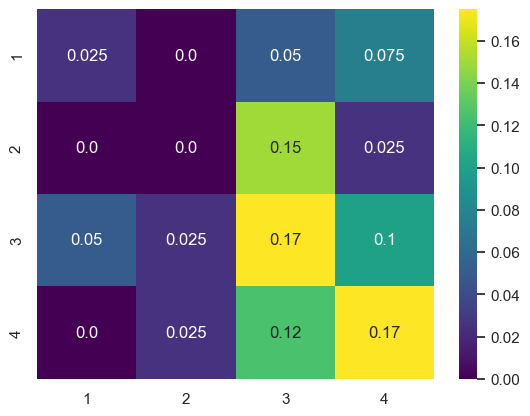

In [34]:
rf = RandomForestClassifier(n_estimators=100, random_state=67, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm / np.sum(cm),
    annot=True,
    fmt=".2",
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels,
)

<Axes: >

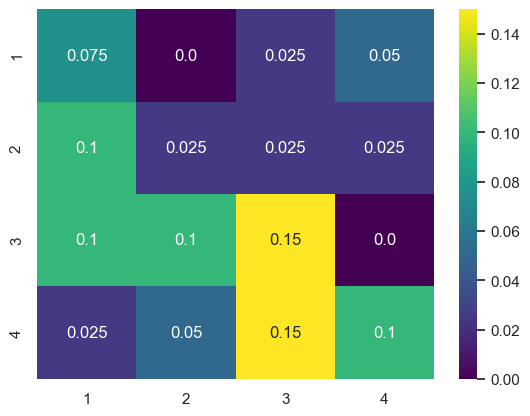

In [37]:
svc = SVC(random_state=67, class_weight=class_weights)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm / np.sum(cm),
    annot=True,
    fmt=".2",
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels,
)